# Tugas Praktikum 1: Scraping & Eksplorasi Data (EDA)

## Paldex.gg | Palworld Item Database

**Unit observasi:** 1 baris = 1 item Palworld

**Lima fitur utama yang dianalisis:**
1. `price` — harga item
2. `weight` — berat item
3. `stackable` — status dapat ditumpuk atau tidak
4. `rarity` — tingkat kelangkaan
5. `category` — kategori item

`name` digunakan sebagai identifier item dan `url` disimpan sebagai referensi sumber.


## 0. Persiapan

Library utama yang digunakan adalah `requests`, `BeautifulSoup`, `pandas`, `matplotlib`, dan `seaborn`.

In [106]:
import os
import re
import time
import threading
import random
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from bs4 import BeautifulSoup
from urllib.parse import urljoin
from concurrent.futures import ThreadPoolExecutor, as_completed
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

from IPython.display import display


# 1. Scraping Dataset

Scraping dilakukan menggunakan `Requests` dan `BeautifulSoup`. Untuk mempercepat proses pengambilan banyak halaman, beberapa URL diproses secara bersamaan menggunakan `ThreadPoolExecutor`.

Metode concurrent request digunakan untuk efisiensi waktu, bukan untuk melewati CAPTCHA, rate limit, atau mekanisme keamanan situs.


In [107]:
# KONFIGURASI SCRAPING

BASE_URL = "https://paldex.gg"
SITEMAP_URL = urljoin(BASE_URL, "/sitemap.xml")

RAW_OUTPUT = "raw_paldex_items.csv"
CHECKPOINT_OUTPUT = "paldex_scrape_checkpoint_category.csv"

TARGET_ROWS = 1500

# Jumlah request bersamaan.
# 6 adalah nilai awal yang cukup seimbang antara kecepatan dan beban server.
MAX_WORKERS = 6

# Checkpoint setiap N record berhasil.
CHECKPOINT_EVERY = 100

# Jeda kecil di masing-masing worker.
REQUEST_DELAY_MIN = 0.15
REQUEST_DELAY_MAX = 0.35

HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/140.0.0.0 Safari/537.36"
    ),
    "Accept": (
        "text/html,application/xhtml+xml,"
        "application/xml;q=0.9,*/*;q=0.8"
    ),
    "Accept-Language": "en-US,en;q=0.9",
}


In [108]:
# SESSION PER THREAD

thread_local = threading.local()


def get_session():
    """Membuat requests.Session untuk setiap worker."""

    if not hasattr(thread_local, "session"):

        session = requests.Session()
        session.headers.update(HEADERS)

        retry_strategy = Retry(
            total=2,
            backoff_factor=0.5,
            status_forcelist=[500, 502, 503, 504],
            allowed_methods=["GET"],
        )

        adapter = HTTPAdapter(
            max_retries=retry_strategy,
            pool_connections=MAX_WORKERS,
            pool_maxsize=MAX_WORKERS,
        )

        session.mount("https://", adapter)
        session.mount("http://", adapter)

        thread_local.session = session

    return thread_local.session


def normalize_text(text):
    if text is None:
        return None

    return re.sub(r"\s+", " ", str(text)).strip()


def get_page(url, timeout=30):
    """GET request tanpa bypass terhadap pembatasan server."""

    session = get_session()

    response = session.get(
        url,
        timeout=timeout
    )

    if response.status_code == 403:
        raise PermissionError(
            f"HTTP 403: akses ditolak untuk {url}"
        )

    if response.status_code == 429:
        raise PermissionError(
            f"HTTP 429: rate limit untuk {url}"
        )

    response.raise_for_status()

    return response.text


### 1.1 Mengambil daftar URL item

Sitemap digunakan untuk memperoleh daftar halaman item sehingga scraper tidak perlu menelusuri pagination secara manual.


In [109]:
# AMBIL SITEMAP

xml_text = get_page(SITEMAP_URL)

print("Sitemap berhasil diambil")
print("Ukuran response:", len(xml_text), "bytes")


Sitemap berhasil diambil
Ukuran response: 274938 bytes


In [110]:
# EKSTRAK URL ITEM

def extract_item_urls(xml_text):
    soup = BeautifulSoup(
        xml_text,
        "xml"
    )

    urls = []

    for loc in soup.find_all("loc"):
        url = normalize_text(
            loc.get_text()
        )

        if url and "/items/" in url:
            urls.append(url)

    return sorted(set(urls))


item_urls = extract_item_urls(
    xml_text
)

print("Jumlah URL item:", len(item_urls))

print("\n10 URL pertama:")
for url in item_urls[:10]:
    print("-", url)

assert len(item_urls) >= TARGET_ROWS, (
    f"Jumlah URL item hanya {len(item_urls)}; "
    f"belum memenuhi target {TARGET_ROWS}."
)

print(
    f"\nTersedia minimal {TARGET_ROWS} URL item."
)


Jumlah URL item: 1594

10 URL pertama:
- https://paldex.gg/items/
- https://paldex.gg/items/ability-glasses/
- https://paldex.gg/items/advanced-arrow/
- https://paldex.gg/items/advanced-bow-schematic-1/
- https://paldex.gg/items/advanced-bow-schematic-2/
- https://paldex.gg/items/advanced-bow-schematic-3/
- https://paldex.gg/items/advanced-bow-schematic-4/
- https://paldex.gg/items/advanced-bow/
- https://paldex.gg/items/advanced-fishing-rod-depresso-schematic/
- https://paldex.gg/items/advanced-fishing-rod-depresso/

Tersedia minimal 1500 URL item.


### 1.2 Fungsi ekstraksi field

Halaman item Paldex menampilkan informasi utama seperti `PRICE`, `WEIGHT`, `STACKABLE`, dan `RARITY`. Kategori item diambil dari breadcrumb yang tampil tepat sebelum nama item.


In [111]:
# FUNGSI EKSTRAK FIELD

def extract_label_value(lines, label, look_ahead=4):
    """Mengambil nilai pertama setelah label tertentu."""

    target = normalize_text(label).upper()

    for i, line in enumerate(lines):

        if normalize_text(line).upper() == target:

            for candidate in lines[
                i + 1 : i + 1 + look_ahead
            ]:
                candidate = normalize_text(candidate)

                if candidate:
                    return candidate

    return None


def extract_category(lines, item_name):
    """Mengambil category/subcategory dari baris sebelum nama item.

    Contoh pola:
        Accessories · Accessory
        Ability Glasses

    Menghasilkan:
        category = Accessories
        subcategory = Accessory
    """

    item_name = normalize_text(item_name)

    if not item_name:
        return None, None

    # Cari posisi nama item pada daftar baris.
    for i, line in enumerate(lines):

        if normalize_text(line) == item_name:

            # Baris non-kosong sebelumnya biasanya breadcrumb.
            if i > 0:

                breadcrumb = normalize_text(
                    lines[i - 1]
                )

                if "·" in breadcrumb:

                    parts = [
                        normalize_text(part)
                        for part in breadcrumb.split("·")
                    ]

                    parts = [
                        part
                        for part in parts
                        if part
                    ]

                    category = parts[0] if len(parts) >= 1 else None
                    subcategory = parts[1] if len(parts) >= 2 else None

                    return category, subcategory

                return breadcrumb, None

    return None, None


### 1.3 Parser item

Parser menghasilkan:

- `name`
- `price_raw`
- `weight_raw`
- `stackable_raw`
- `rarity_raw`
- `category_raw`
- `subcategory_raw`
- `url`

`price_raw`, `weight_raw`, dan atribut lain tetap disimpan dalam bentuk mentah agar dataset raw dapat dipertanggungjawabkan.


In [112]:
# PARSER ITEM

def parse_item_page(url):

    html = get_page(url)

    soup = BeautifulSoup(
        html,
        "html.parser"
    )

    # ----------------------------------------
    # NAMA ITEM
    # ----------------------------------------

    h1 = soup.find("h1")

    name = (
        normalize_text(
            h1.get_text(" ", strip=True)
        )
        if h1
        else None
    )

    # ----------------------------------------
    # SEMUA TEKS HALAMAN
    # ----------------------------------------

    lines = [
        normalize_text(line)
        for line in soup.get_text(
            "\n",
            strip=True
        ).split("\n")
        if normalize_text(line)
    ]

    # ----------------------------------------
    # FITUR UTAMA
    # ----------------------------------------

    price_raw = extract_label_value(
        lines,
        "PRICE"
    )

    weight_raw = extract_label_value(
        lines,
        "WEIGHT"
    )

    stackable_raw = extract_label_value(
        lines,
        "STACKABLE"
    )

    rarity_raw = extract_label_value(
        lines,
        "RARITY"
    )

    # ----------------------------------------
    # CATEGORY
    # ----------------------------------------

    category_raw, subcategory_raw = extract_category(
        lines,
        name
    )

    return {
        "name": name,
        "price_raw": price_raw,
        "weight_raw": weight_raw,
        "stackable_raw": stackable_raw,
        "rarity_raw": rarity_raw,
        "category_raw": category_raw,
        "subcategory_raw": subcategory_raw,
        "url": url,
    }


### 1.4 Uji parser pada satu item

Sebelum menjalankan ribuan request, parser diuji terlebih dahulu pada satu halaman.


In [113]:
# TEST SATU ITEM

test_url = "https://paldex.gg/items/ability-glasses/"

test_record = parse_item_page(
    test_url
)

display(
    pd.Series(test_record)
)


name                                        Ability Glasses
price_raw                                           51,600G
weight_raw                                                1
stackable_raw                                            No
rarity_raw                                             RARE
category_raw                                      Accessory
subcategory_raw                                         NaN
url                https://paldex.gg/items/ability-glasses/
dtype: str

In [114]:
# CEK FIELD HASIL TEST

expected_fields = [
    "name",
    "price_raw",
    "weight_raw",
    "stackable_raw",
    "rarity_raw",
    "category_raw",
    "subcategory_raw",
    "url",
]

print("Field hasil parser:")

for field in expected_fields:
    value = test_record.get(field)

    status = "✅" if value is not None else "⚠️"

    print(
        f"{status} {field}: {value}"
    )


Field hasil parser:
✅ name: Ability Glasses
✅ price_raw: 51,600G
✅ weight_raw: 1
✅ stackable_raw: No
✅ rarity_raw: RARE
✅ category_raw: Accessory
⚠️ subcategory_raw: None
✅ url: https://paldex.gg/items/ability-glasses/


### 1.5 Scraping cepat dengan concurrent requests

Beberapa halaman diproses secara paralel menggunakan `ThreadPoolExecutor`. Hasil disimpan secara berkala ke checkpoint sehingga proses dapat dilanjutkan tanpa mengulang seluruh request apabila notebook berhenti.


In [115]:
# WORKER SCRAPING

def scrape_one(url):

    try:

        # Jeda kecil agar worker tidak mengirim burst tanpa jeda.
        time.sleep(
            random.uniform(
                REQUEST_DELAY_MIN,
                REQUEST_DELAY_MAX
            )
        )

        data = parse_item_page(
            url
        )

        return {
            "success": True,
            "data": data,
            "url": url,
            "error": None,
            "blocked": False,
        }

    except PermissionError as exc:

        return {
            "success": False,
            "data": None,
            "url": url,
            "error": str(exc),
            "blocked": True,
        }

    except Exception as exc:

        return {
            "success": False,
            "data": None,
            "url": url,
            "error": str(exc),
            "blocked": False,
        }


In [116]:
# LOAD CHECKPOINT

records = []
scraped_urls = set()

if os.path.exists(
    CHECKPOINT_OUTPUT
):

    checkpoint_df = pd.read_csv(
        CHECKPOINT_OUTPUT
    )

    records = checkpoint_df.to_dict(
        orient="records"
    )

    if "url" in checkpoint_df.columns:

        scraped_urls = set(
            checkpoint_df["url"]
            .dropna()
            .astype(str)
        )

    print(
        "Checkpoint ditemukan."
    )

    print(
        "Sudah diproses:",
        len(scraped_urls)
    )

else:

    print(
        "Belum ada checkpoint."
    )


remaining_urls = [
    url
    for url in item_urls
    if url not in scraped_urls
]

print(
    "\nTotal URL      :",
    len(item_urls)
)

print(
    "Sudah diproses :",
    len(scraped_urls)
)

print(
    "Sisa           :",
    len(remaining_urls)
)


Checkpoint ditemukan.
Sudah diproses: 1500

Total URL      : 1594
Sudah diproses : 1500
Sisa           : 94


In [117]:
# CONCURRENT SCRAPING

start_time = time.time()

successful = 0
failed = []

print(
    f"Memulai scraping dengan "
    f"{MAX_WORKERS} worker..."
)

with ThreadPoolExecutor(
    max_workers=MAX_WORKERS
) as executor:

    futures = {
        executor.submit(
            scrape_one,
            url
        ): url
        for url in remaining_urls
    }

    completed = 0

    stop_scraping = False

    for future in as_completed(
        futures
    ):

        result = future.result()

        completed += 1

        if result["success"]:

            records.append(
                result["data"]
            )

            successful += 1

        else:

            failed.append({
                "url": result["url"],
                "error": result["error"]
            })

            print(
                f"❌ Gagal: "
                f"{result['url']} → "
                f"{result['error']}"
            )

            # Jangan mencoba bypass pembatasan server.
            if result["blocked"]:

                print(
                    "\n⚠️ Server membatasi akses."
                )

                print(
                    "Scraping dihentikan."
                )

                stop_scraping = True

                for pending in futures:
                    pending.cancel()

                break

        # PROGRESS

        if completed % 25 == 0:

            elapsed = (
                time.time() - start_time
            )

            print(
                f"Progress: "
                f"{completed}/"
                f"{len(remaining_urls)} | "
                f"Berhasil: {successful} | "
                f"Gagal: {len(failed)} | "
                f"Waktu: {elapsed:.1f}s"
            )

        # CHECKPOINT

        if completed % CHECKPOINT_EVERY == 0:

            checkpoint_df = (
                pd.DataFrame(records)
                .drop_duplicates(
                    subset=["url"]
                )
            )

            checkpoint_df.to_csv(
                CHECKPOINT_OUTPUT,
                index=False,
                encoding="utf-8"
            )

            print(
                f"✓ Checkpoint tersimpan: "
                f"{len(checkpoint_df)} record"
            )


elapsed_total = time.time() - start_time

print(
    "\nWaktu scraping:",
    round(elapsed_total, 2),
    "detik"
)


Memulai scraping dengan 6 worker...
Progress: 25/94 | Berhasil: 25 | Gagal: 0 | Waktu: 2.9s
Progress: 50/94 | Berhasil: 50 | Gagal: 0 | Waktu: 6.2s
Progress: 75/94 | Berhasil: 75 | Gagal: 0 | Waktu: 9.2s

Waktu scraping: 12.27 detik


### 1.6 Membuat Raw Dataset

Hasil scraping disatukan menjadi satu DataFrame tanpa melakukan cleaning atau perubahan terhadap isi data. Dataset mentah ini kemudian disimpan dalam format CSV untuk digunakan pada tahap berikutnya.

In [119]:
# RAW DATASET

raw_df = pd.DataFrame(records).reset_index(drop=True)

print("Shape raw dataset:", raw_df.shape)

display(raw_df.head())

Shape raw dataset: (1594, 8)


,name,price_raw,weight_raw,stackable_raw,rarity_raw,category_raw,subcategory_raw,url
0,Advanced Arrow,"1,110G",0.025,Yes,COMMON,Ammo,NaN,https://paldex.gg/items/advanced-arrow/
1,Advanced Bow Schematic 2,"10,000G",0,Yes,RARE,Blueprint,NaN,https://paldex.gg/items/advanced-bow-schematic-2/
2,Advanced Bow Schematic 1,"10,000G",0,Yes,UNCOMMON,Blueprint,NaN,https://paldex.gg/items/advanced-bow-schematic-1/
3,Ability Glasses,"51,600G",1,No,RARE,Accessory,NaN,https://paldex.gg/items/ability-glasses/
4,Palworld Items,Sort:,Sort:,NaN,Sort:,Collapse,NaN,https://paldex.gg/items/


In [120]:
# SIMPAN RAW DATASET

raw_df.to_csv(
    RAW_OUTPUT,
    index=False,
    encoding="utf-8"
)

print("RAW DATASET BERHASIL DISIMPAN")

print("File  :", RAW_OUTPUT)
print("Baris :", raw_df.shape[0])
print("Kolom :", raw_df.shape[1])

RAW DATASET BERHASIL DISIMPAN
File  : raw_paldex_items.csv
Baris : 1594
Kolom : 8


### 1.7 Validasi hasil scraping

Bagian ini memastikan hasil scraping memenuhi syarat jumlah data dan menyediakan lima fitur utama yang akan dianalisis.


In [121]:
# VALIDASI DATASET

required_features = [
    "price_raw",
    "weight_raw",
    "stackable_raw",
    "rarity_raw",
    "category_raw",
]

print(
    "Jumlah baris:",
    raw_df.shape[0]
)

print(
    "Jumlah kolom:",
    raw_df.shape[1]
)

print("\nValidasi lima fitur utama:")

for col in required_features:

    status = "✅" if col in raw_df.columns else "❌"

    print(
        f"{status} {col}"
    )

print("\nMissing value raw:")

display(
    raw_df[required_features]
    .isna()
    .sum()
)


category_missing_pct = (
    raw_df["category_raw"]
    .isna()
    .mean() * 100
)

print(
    f"\nPersentase category kosong: "
    f"{category_missing_pct:.2f}%"
)


Jumlah baris: 1594
Jumlah kolom: 8

Validasi lima fitur utama:
✅ price_raw
✅ weight_raw
✅ stackable_raw
✅ rarity_raw
✅ category_raw

Missing value raw:


price_raw        0
weight_raw       0
stackable_raw    1
rarity_raw       0
category_raw     0
dtype: int64


Persentase category kosong: 0.00%


### 1.8 Contoh Hasil Category

Category merupakan salah satu fitur utama yang digunakan dalam analisis. Pemeriksaan ini dilakukan untuk memastikan hasil scraping pada atribut category berhasil diperoleh dengan baik.

In [122]:
# DISTRIBUSI CATEGORY RAW

display(
    raw_df["category_raw"]
    .value_counts(dropna=False)
    .head(20)
    .rename("Jumlah")
    .to_frame()
)


,Jumlah
category_raw,
Blueprint,490
Pal gear,138
Boss rewards,102
Skill fruits,92
Accessory,81
Head,68
Pal materials,66
Passive items,40
Melee,33


## 2. Import dan Pemahaman Dataset

Dataset hasil scraping yang telah disimpan dalam bentuk CSV diimpor kembali menggunakan Pandas.

Tahap ini dilakukan untuk memahami struktur dataset, jumlah observasi, atribut yang tersedia, dan tipe data setiap atribut.

In [123]:
RAW_OUTPUT = "raw_paldex_items.csv"

raw_df = pd.read_csv(RAW_OUTPUT)

df = raw_df.copy()

print("Raw dataset berhasil diimpor.")
print("Shape:", df.shape)

display(df.head())

Raw dataset berhasil diimpor.
Shape: (1594, 8)


,name,price_raw,weight_raw,stackable_raw,rarity_raw,category_raw,subcategory_raw,url
0,Advanced Arrow,"1,110G",0.025,Yes,COMMON,Ammo,NaN,https://paldex.gg/items/advanced-arrow/
1,Advanced Bow Schematic 2,"10,000G",0,Yes,RARE,Blueprint,NaN,https://paldex.gg/items/advanced-bow-schematic-2/
2,Advanced Bow Schematic 1,"10,000G",0,Yes,UNCOMMON,Blueprint,NaN,https://paldex.gg/items/advanced-bow-schematic-1/
3,Ability Glasses,"51,600G",1,No,RARE,Accessory,NaN,https://paldex.gg/items/ability-glasses/
4,Palworld Items,Sort:,Sort:,NaN,Sort:,Collapse,NaN,https://paldex.gg/items/


### 2.1 Lima Baris Pertama

Lima baris pertama dataset ditampilkan untuk memahami struktur dan isi awal data.

In [124]:
df.head()

,name,price_raw,weight_raw,stackable_raw,rarity_raw,category_raw,subcategory_raw,url
0,Advanced Arrow,"1,110G",0.025,Yes,COMMON,Ammo,NaN,https://paldex.gg/items/advanced-arrow/
1,Advanced Bow Schematic 2,"10,000G",0,Yes,RARE,Blueprint,NaN,https://paldex.gg/items/advanced-bow-schematic-2/
2,Advanced Bow Schematic 1,"10,000G",0,Yes,UNCOMMON,Blueprint,NaN,https://paldex.gg/items/advanced-bow-schematic-1/
3,Ability Glasses,"51,600G",1,No,RARE,Accessory,NaN,https://paldex.gg/items/ability-glasses/
4,Palworld Items,Sort:,Sort:,NaN,Sort:,Collapse,NaN,https://paldex.gg/items/


### 2.2 Informasi Umum Dataset

Informasi umum dataset ditampilkan menggunakan `info()`, `shape`, dan `dtypes`.

In [125]:
# Informasi umum dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1594 entries, 0 to 1593
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             1594 non-null   str    
 1   price_raw        1594 non-null   str    
 2   weight_raw       1594 non-null   str    
 3   stackable_raw    1593 non-null   str    
 4   rarity_raw       1594 non-null   str    
 5   category_raw     1594 non-null   str    
 6   subcategory_raw  0 non-null      float64
 7   url              1594 non-null   str    
dtypes: float64(1), str(7)
memory usage: 99.8 KB


In [126]:
print("Jumlah baris  :", df.shape[0])
print("Jumlah kolom :", df.shape[1])

print("\nNama kolom:")
print(df.columns.tolist())

Jumlah baris  : 1594
Jumlah kolom : 8

Nama kolom:
['name', 'price_raw', 'weight_raw', 'stackable_raw', 'rarity_raw', 'category_raw', 'subcategory_raw', 'url']


In [127]:
print("Tipe data setiap atribut:")

display(
    df.dtypes.to_frame("Data Type")
)

Tipe data setiap atribut:


,Data Type
name,str
price_raw,str
weight_raw,str
stackable_raw,str
rarity_raw,str
category_raw,str
subcategory_raw,float64
url,str


## 3. Preprocessing Awal

Pada tahap ini, atribut hasil scraping yang masih berupa teks diubah ke tipe data yang sesuai agar dapat digunakan untuk analisis statistik dan visualisasi.

Lima fitur utama yang digunakan:

- `price`
- `weight`
- `stackable`
- `rarity`
- `category`

`name` digunakan sebagai identifier, sedangkan `url` digunakan sebagai referensi sumber.

In [128]:
# CLEANING AWAL

before_cleaning = len(df)

# Hapus duplikasi berdasarkan URL
df = df.drop_duplicates(
    subset=["url"]
).copy()

# Hapus halaman indeks /items/ yang bukan item individual
df = df[
    df["url"] != "https://paldex.gg/items/"
].copy()

# Reset index setelah cleaning
df = df.reset_index(drop=True)

after_cleaning = len(df)

print("Jumlah baris sebelum cleaning :", before_cleaning)
print("Jumlah baris setelah cleaning :", after_cleaning)
print("Jumlah baris dihapus          :", before_cleaning - after_cleaning)

display(
    df.head()
)

Jumlah baris sebelum cleaning : 1594
Jumlah baris setelah cleaning : 1593
Jumlah baris dihapus          : 1


,name,price_raw,weight_raw,stackable_raw,rarity_raw,category_raw,subcategory_raw,url
0,Advanced Arrow,"1,110G",0.025,Yes,COMMON,Ammo,NaN,https://paldex.gg/items/advanced-arrow/
1,Advanced Bow Schematic 2,"10,000G",0,Yes,RARE,Blueprint,NaN,https://paldex.gg/items/advanced-bow-schematic-2/
2,Advanced Bow Schematic 1,"10,000G",0,Yes,UNCOMMON,Blueprint,NaN,https://paldex.gg/items/advanced-bow-schematic-1/
3,Ability Glasses,"51,600G",1,No,RARE,Accessory,NaN,https://paldex.gg/items/ability-glasses/
4,Advanced Bow,"170,160G",25,No,COMMON,Bows,NaN,https://paldex.gg/items/advanced-bow/


In [129]:
# PREPROCESSING

# Fungsi konversi numerik
def parse_number_safe(value):
    if pd.isna(value):
        return np.nan

    value = str(value)

    match = re.search(
        r"\d[\d,]*(?:\.\d+)?",
        value
    )

    if match is None:
        return np.nan

    try:
        return float(
            match.group(0).replace(",", "")
        )
    except ValueError:
        return np.nan


# Konversi fitur numerik
df["price"] = df["price_raw"].apply(
    parse_number_safe
)

df["weight"] = df["weight_raw"].apply(
    parse_number_safe
)


# Konversi Stackable
def parse_stackable_safe(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip().lower()

    if value.startswith("yes"):
        return "Yes"

    if value.startswith("no"):
        return "No"

    return np.nan


df["stackable"] = df[
    "stackable_raw"
].apply(parse_stackable_safe)


# Konversi Rarity
def parse_rarity_safe(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip().upper()

    rarity_levels = [
        "COMMON",
        "UNCOMMON",
        "RARE",
        "EPIC",
        "LEGENDARY"
    ]

    for rarity in rarity_levels:
        if value.startswith(rarity):
            return rarity

    return np.nan


df["rarity"] = df[
    "rarity_raw"
].apply(parse_rarity_safe)


# Category
df["category"] = df[
    "category_raw"
].apply(normalize_text)


# Pilih kolom final
final_columns = [
    "name",
    "price",
    "weight",
    "stackable",
    "rarity",
    "category",
    "url"
]

df = (
    df[final_columns]
    .drop_duplicates(subset=["url"])
    .reset_index(drop=True)
)

print("Shape dataset setelah preprocessing:")
print(df.shape)

display(df.head())

Shape dataset setelah preprocessing:
(1593, 7)


,name,price,weight,stackable,rarity,category,url
0,Advanced Arrow,1110.0,0.025,Yes,COMMON,Ammo,https://paldex.gg/items/advanced-arrow/
1,Advanced Bow Schematic 2,10000.0,0.000,Yes,RARE,Blueprint,https://paldex.gg/items/advanced-bow-schematic-2/
2,Advanced Bow Schematic 1,10000.0,0.000,Yes,UNCOMMON,Blueprint,https://paldex.gg/items/advanced-bow-schematic-1/
3,Ability Glasses,51600.0,1.000,No,RARE,Accessory,https://paldex.gg/items/ability-glasses/
4,Advanced Bow,170160.0,25.000,No,COMMON,Bows,https://paldex.gg/items/advanced-bow/


## 4. Identifikasi Tipe Atribut

Berdasarkan karakteristik datanya, atribut diklasifikasikan menjadi nominal, ordinal, numerik diskrit, dan numerik kontinu.

| Atribut     | Tipe Atribut        | Keterangan                                                         |
| ----------- | ------------------- | ------------------------------------------------------------------ |
| `price`     | **Numerik diskrit** | Harga item dalam Gold dan nilai pada dataset berupa bilangan bulat |
| `weight`    | **Numerik kontinu** | Berat item dapat memiliki nilai desimal                            |
| `stackable` | Nominal             | Status apakah item dapat ditumpuk                                  |
| `rarity`    | Ordinal             | Tingkat rarity memiliki urutan dari COMMON hingga LEGENDARY        |
| `category`  | Nominal             | Kategori/jenis item                                                |
| `name`      | Identifier/Nominal  | Nama item sebagai identitas item                                   |
| `url`       | Identifier          | URL sebagai referensi sumber item                                  |


Lima fitur utama yang digunakan dalam analisis adalah `price`, `weight`, `stackable`, `rarity`, dan `category`.

## 5. Analisis Statistik dan Kualitas Data

Analisis statistik dilakukan untuk mengetahui karakteristik numerik dan kategorikal dataset.

Analisis meliputi statistik deskriptif, distribusi kategorikal, missing value, dan outlier.

### 5.1 Statistik Deskriptif Atribut Numerik

Atribut numerik yang dianalisis adalah `price` dan `weight`.

Statistik yang digunakan:
- mean
- median
- modus
- standar deviasi
- minimum
- maksimum

In [130]:
# STATISTIK DESKRIPTIF

numeric_features = [
    "price",
    "weight"
]

stats = []

for col in numeric_features:

    series = df[col].dropna()

    mode_values = series.mode()

    stats.append({
        "Atribut": col,
        "Mean": series.mean(),
        "Median": series.median(),
        "Modus": (
            mode_values.iloc[0]
            if not mode_values.empty
            else np.nan
        ),
        "Std": series.std(),
        "Min": series.min(),
        "Max": series.max()
    })

stats_df = pd.DataFrame(stats)

display(
    stats_df.round(2)
)

,Atribut,Mean,Median,Modus,Std,Min,Max
0,price,58011.09,10000.0,10000.0,349463.18,1.0,6508680.0
1,weight,2.82,0.0,0.0,7.79,0.0,50.0


### 5.2 Distribusi Atribut Kategorikal

Distribusi kategorikal digunakan untuk melihat frekuensi kemunculan setiap kategori pada atribut `stackable`, `rarity`, dan `category`.

In [131]:
# Distribusi Stackable

print("STACKABLE")

stackable_counts = (
    df["stackable"]
    .value_counts(dropna=False)
)

display(
    stackable_counts
    .rename("Jumlah")
    .to_frame()
)


# Distribusi Rarity

print("\nRARITY")

rarity_order = [
    "COMMON",
    "UNCOMMON",
    "RARE",
    "EPIC",
    "LEGENDARY"
]

rarity_counts = (
    df["rarity"]
    .value_counts(dropna=False)
    .reindex(
        rarity_order,
        fill_value=0
    )
)

display(
    rarity_counts
    .rename("Jumlah")
    .to_frame()
)


# Distribusi Category

print("\nCATEGORY")

category_counts = (
    df["category"]
    .value_counts(dropna=False)
)

display(
    category_counts
    .rename("Jumlah")
    .to_frame()
)

STACKABLE


,Jumlah
stackable,
Yes,1263
No,330



RARITY


,Jumlah
rarity,
COMMON,452
UNCOMMON,250
RARE,299
EPIC,337
LEGENDARY,255



CATEGORY


,Jumlah
category,
Blueprint,490
Pal gear,138
Boss rewards,102
Skill fruits,92
Accessory,81
...,...
Stone,1
Revival,1
Level-up,1


### 5.3 Analisis Missing Value

Missing value diperiksa pada setiap atribut untuk mengetahui jumlah dan persentase data yang tidak tersedia.

In [132]:
# MISSING VALUE

missing_summary = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing Percentage (%)": (
        df.isna().mean() * 100
    ).round(2)
})

missing_summary = (
    missing_summary
    .sort_values(
        "Missing Count",
        ascending=False
    )
)

display(missing_summary)

,Missing Count,Missing Percentage (%)
price,142,8.91
name,0,0.00
weight,0,0.00
stackable,0,0.00
rarity,0,0.00
category,0,0.00
url,0,0.00


In [133]:
# Baris yang memiliki missing value

missing_rows = df[
    df.isna().any(axis=1)
]

print(
    "Jumlah baris yang memiliki "
    "minimal satu missing value:",
    len(missing_rows)
)

display(
    missing_rows.head(10)
)

Jumlah baris yang memiliki minimal satu missing value: 142


,name,price,weight,stackable,rarity,category,url
12,Aegidron Saddle,NaN,0.0,Yes,LEGENDARY,Pal gear,https://paldex.gg/items/aegidron-saddle/
69,Arsox Saddle,NaN,0.0,Yes,COMMON,Pal gear,https://paldex.gg/items/arsox-saddle/
77,Astegon Saddle,NaN,0.0,Yes,RARE,Pal gear,https://paldex.gg/items/astegon-saddle/
82,Azurobe Saddle,NaN,0.0,Yes,UNCOMMON,Pal gear,https://paldex.gg/items/azurobe-saddle/
84,Azurobe Cryst Saddle,NaN,0.0,Yes,UNCOMMON,Pal gear,https://paldex.gg/items/azurobe-cryst-saddle/
85,Bastigor's Hammer,NaN,0.0,Yes,LEGENDARY,Pal gear,https://paldex.gg/items/bastigor-s-hammer/
86,Azurmane Saddle,NaN,0.0,Yes,EPIC,Pal gear,https://paldex.gg/items/azurmane-saddle/
92,Beakon Saddle,NaN,0.0,Yes,UNCOMMON,Pal gear,https://paldex.gg/items/beakon-saddle/
94,Beakon Cryst Saddle,NaN,0.0,Yes,UNCOMMON,Pal gear,https://paldex.gg/items/beakon-cryst-saddle/
125,Blazamut Ryu Saddle,NaN,0.0,Yes,LEGENDARY,Pal gear,https://paldex.gg/items/blazamut-ryu-saddle/


### Penanganan Missing Value

Berdasarkan pemeriksaan missing value, hanya atribut price yang memiliki nilai kosong, yaitu sebanyak 142 data atau 8,91%. Missing value pada price tidak langsung dihapus maupun diisi dengan nilai tertentu karena nilai harga yang hilang tidak dapat ditentukan secara pasti dari data yang tersedia. Untuk analisis yang membutuhkan atribut price, baris dengan price kosong diabaikan menggunakan dropna(). Atribut lainnya tidak memiliki missing value pada dataset final.

### 5.4 Deteksi Outlier

Outlier pada atribut numerik dideteksi menggunakan metode Interquartile Range (IQR).

Rumus:
- IQR = Q3 − Q1
- Lower Bound = Q1 − 1.5 × IQR
- Upper Bound = Q3 + 1.5 × IQR

Data yang berada di luar batas tersebut dikategorikan sebagai kandidat outlier.

In [134]:
# DETEKSI OUTLIER DENGAN IQR

def detect_outliers_iqr(data, column):

    series = data[column].dropna()

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    mask = (
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    )

    return {
        "Atribut": column,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Jumlah Outlier": int(mask.sum()),
        "Persentase (%)": round(
            mask.mean() * 100,
            2
        )
    }


outlier_summary = pd.DataFrame([
    detect_outliers_iqr(
        df,
        col
    )
    for col in numeric_features
])

display(
    outlier_summary.round(2)
)

,Atribut,Q1,Q3,IQR,Lower Bound,Upper Bound,Jumlah Outlier,Persentase (%)
0,price,290.0,10000.0,9710.0,-14275.0,24565.0,187,11.74
1,weight,0.0,1.0,1.0,-1.5,2.5,278,17.45


In [135]:
# Menampilkan contoh outlier

for col in numeric_features:

    series = df[col].dropna()

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ].sort_values(
        col,
        ascending=False
    )

    print(f"\nOutlier pada {col}:")

    display(
        outliers[
            ["name", col, "rarity", "category"]
        ].head(10)
    )


Outlier pada price:


,name,price,rarity,category
1563,Wing Pack,6508680.0,LEGENDARY,Glider
100,Beam Launcher,5137080.0,COMMON,Rocket launchers
1183,Plasma Rifle,4134020.0,COMMON,Assault rifles
386,Drone Launcher,4041020.0,COMMON,Melee
104,Beam Scatter,2933640.0,COMMON,Shotguns
918,Lightweight Ancient Armor,2751100.0,COMMON,Body
708,Heavy Assault Rifle,2512320.0,COMMON,Assault rifles
1448,Tactical Grenade Launcher,2295540.0,COMMON,Rocket launchers
666,Heat-Resistant Ancient Armor,2189330.0,COMMON,Body
1223,Prototype Shotgun,2150100.0,COMMON,Shotguns



Outlier pada weight:


,name,weight,rarity,category
531,Gatling Gun,50.0,COMMON,Gatling guns
739,Huge Common Egg,50.0,LEGENDARY,Pal eggs
741,Huge Damp Egg,50.0,LEGENDARY,Pal eggs
740,Huge Dark Egg,50.0,LEGENDARY,Pal eggs
742,Huge Electric Egg,50.0,LEGENDARY,Pal eggs
1177,Plasma Multicutter,50.0,LEGENDARY,Melee
890,Laser Gatling Gun,50.0,COMMON,Gatling guns
749,Huge Frozen Egg,50.0,LEGENDARY,Pal eggs
750,Huge Verdant Egg,50.0,LEGENDARY,Pal eggs
748,Huge Ominous Egg,50.0,LEGENDARY,Pal eggs


### Penanganan Outlier

Outlier tidak langsung dihapus dari dataset karena nilai ekstrem dapat merupakan nilai yang valid. Misalnya, item tertentu dapat memiliki harga atau berat yang jauh lebih tinggi daripada mayoritas item lainnya.

Oleh karena itu, outlier akan dipertahankan dan digunakan sebagai bagian dari interpretasi distribusi data.

## 6. Visualisasi Data

Visualisasi digunakan untuk memahami distribusi atribut dan hubungan antaratribut.

Jenis visualisasi yang digunakan:
- histogram,
- bar chart,
- scatter plot,
- boxplot,
- correlation heatmap.

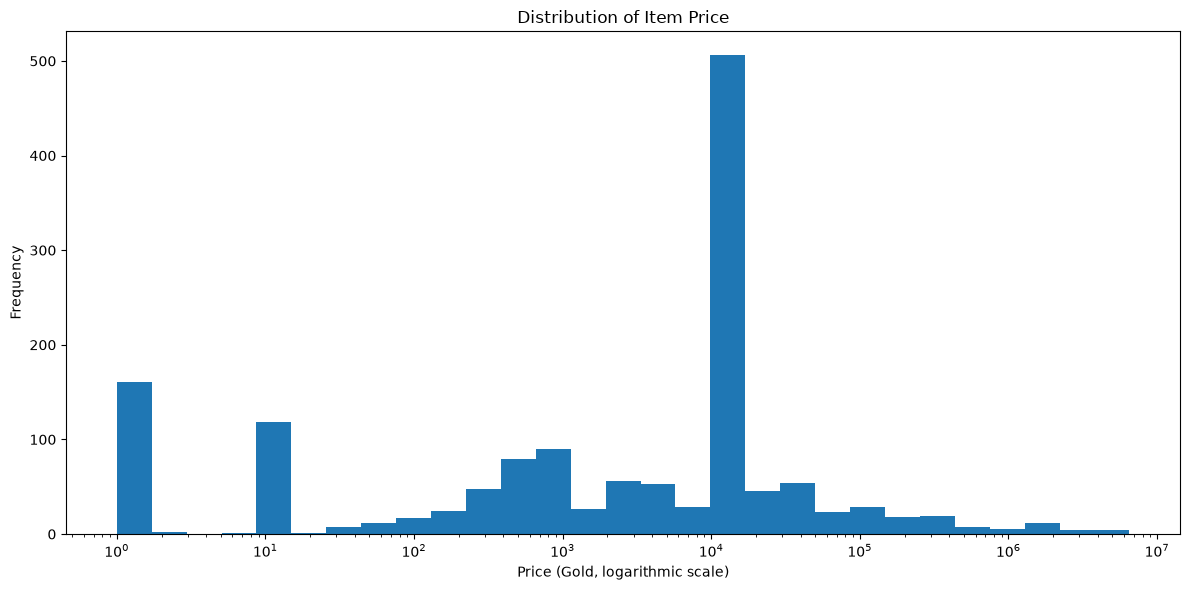

In [136]:
# DISTRIBUTION OF ITEM PRICE

price = df["price"].dropna()
price = price[price > 0]

# Membuat bin secara logaritmik
bins = np.logspace(
    np.log10(price.min()),
    np.log10(price.max()),
    30
)

plt.figure(figsize=(12, 6))

plt.hist(price, bins=bins)

plt.xscale("log")

plt.title("Distribution of Item Price")
plt.xlabel("Price (Gold, logarithmic scale)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

**Interpretasi**: Distribusi harga menunjukkan sebagian besar item memiliki harga relatif rendah, sedangkan hanya sebagian kecil item memiliki harga yang sangat tinggi. Hal ini menunjukkan distribusi harga yang cenderung miring ke kanan (right-skewed) dan terdapat beberapa nilai ekstrem.

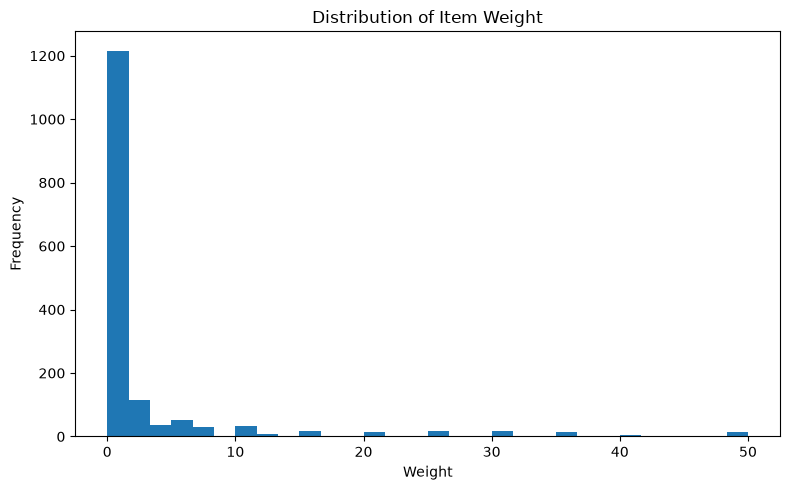

In [137]:
# DISTRIBUTION OF ITEM WEIGHT

plt.figure(figsize=(8, 5))

plt.hist(
    df["weight"].dropna(),
    bins=30
)

plt.xlabel("Weight")
plt.ylabel("Frequency")
plt.title("Distribution of Item Weight")

plt.tight_layout()
plt.show()

**Interpretasi:** Sebagian besar item memiliki berat yang rendah, terutama di sekitar nilai 0–1. Hanya sebagian kecil item yang memiliki berat jauh lebih besar, sehingga distribusi berat juga menunjukkan kemencengan ke kanan dan beberapa nilai ekstrem.

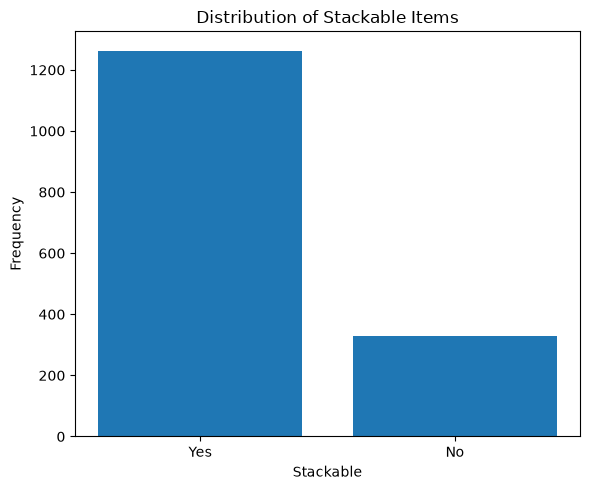

In [138]:
# DISTRIBUTION OF STACKABLE ITEMS

stackable_counts = (
    df["stackable"]
    .value_counts()
)

plt.figure(figsize=(6, 5))

plt.bar(
    stackable_counts.index,
    stackable_counts.values
)

plt.xlabel("Stackable")
plt.ylabel("Frequency")
plt.title("Distribution of Stackable Items")

plt.tight_layout()
plt.show()

**Interpretasi**: Item yang dapat ditumpuk (Yes) jauh lebih banyak dibandingkan item yang tidak dapat ditumpuk (No). Dari 1.593 data, terdapat 1.263 item yang dapat ditumpuk dan 330 item yang tidak dapat ditumpuk.

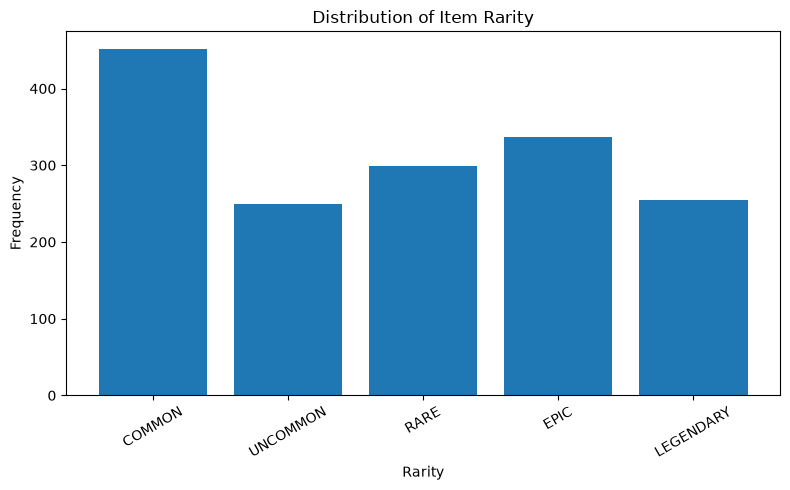

In [139]:
# DISTRIBUTION OF ITEM RARITY

rarity_counts = (
    df["rarity"]
    .value_counts()
    .reindex(
        rarity_order,
        fill_value=0
    )
)

plt.figure(figsize=(8, 5))

plt.bar(
    rarity_counts.index,
    rarity_counts.values
)

plt.xlabel("Rarity")
plt.ylabel("Frequency")
plt.title("Distribution of Item Rarity")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

**Interpretasi**: Rarity COMMON merupakan kategori yang paling banyak ditemukan dengan 452 item, sedangkan UNCOMMON merupakan kategori dengan jumlah paling sedikit, yaitu 250 item. Kategori lainnya berada di antara kedua jumlah tersebut.

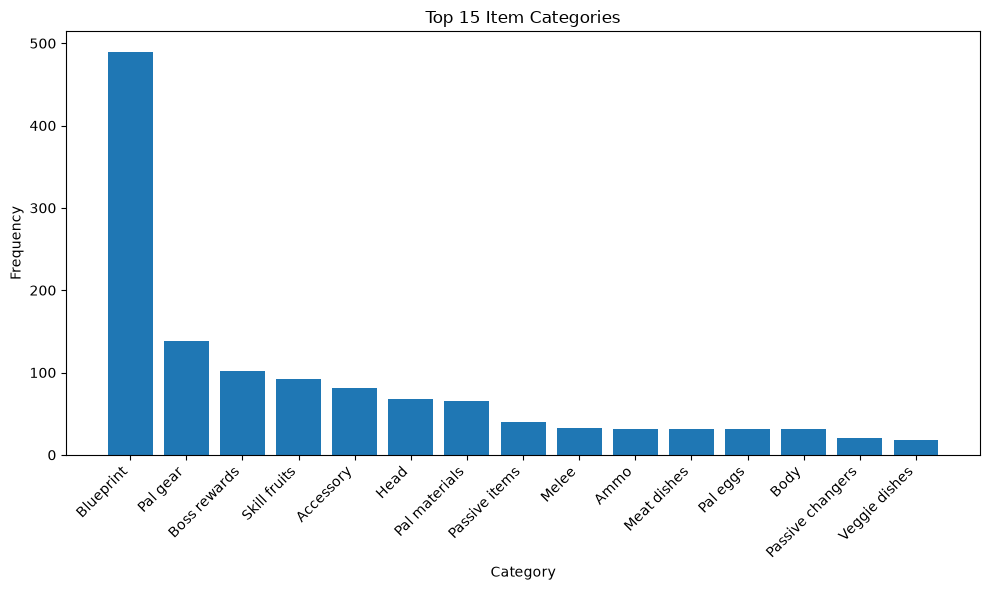

In [140]:
# TOP 15 ITME CATEGORIES

top_categories = (
    df["category"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(10, 6))

plt.bar(
    top_categories.index.astype(str),
    top_categories.values
)

plt.xlabel("Category")
plt.ylabel("Frequency")
plt.title("Top 15 Item Categories")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

**Interpretasi**: Kategori Blueprint memiliki jumlah item paling banyak, yaitu 490 item, dan terlihat jauh lebih dominan dibandingkan kategori lainnya. Setelah itu, jumlah item menurun pada kategori seperti Pal gear, Boss rewards, dan Skill fruits.

### 6.1 Hubungan Price dan Weight

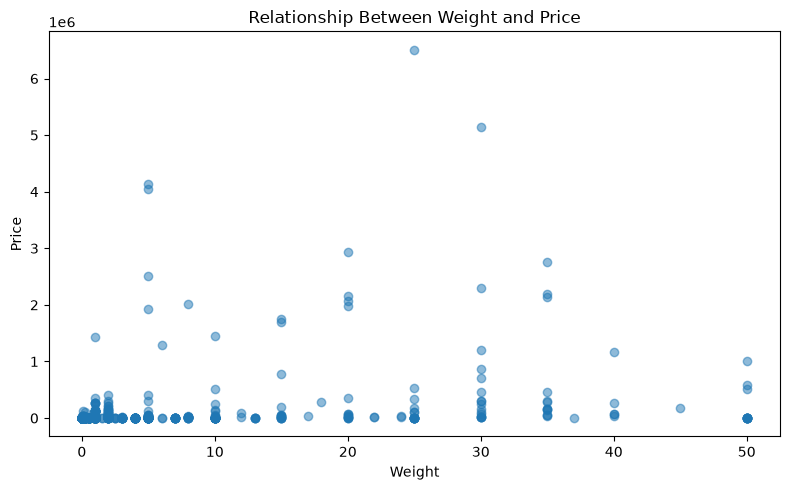

In [141]:
plot_df = df[
    ["price", "weight"]
].dropna()

plt.figure(figsize=(8, 5))

plt.scatter(
    plot_df["weight"],
    plot_df["price"],
    alpha=0.5
)

plt.xlabel("Weight")
plt.ylabel("Price")
plt.title("Relationship Between Weight and Price")

plt.tight_layout()
plt.show()

**Interpretasi:** Scatter plot menunjukkan bahwa hubungan antara berat dan harga tidak terlalu kuat. Sebagian besar data terkonsentrasi pada harga rendah meskipun memiliki berat yang berbeda, sementara beberapa item dengan berat tertentu memiliki harga yang sangat tinggi.

### 6.2 Distribusi Price Berdasarkan Rarity

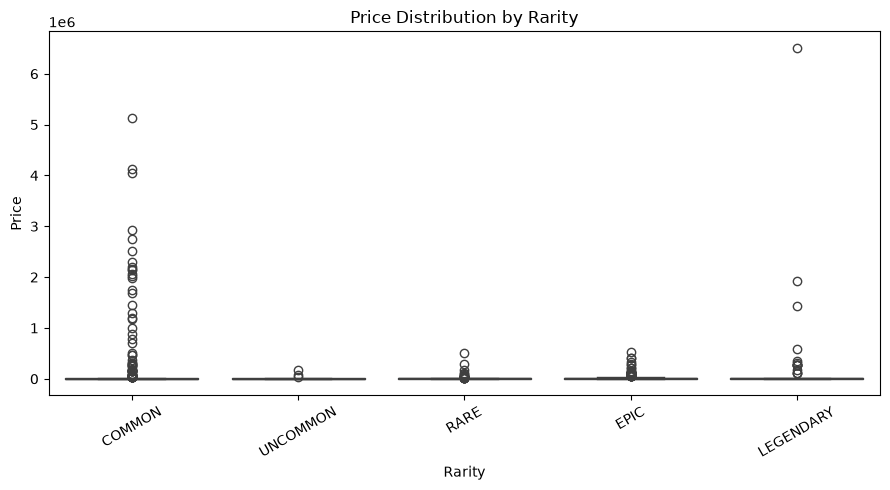

In [142]:
boxplot_df = df[
    ["rarity", "price"]
].dropna()

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=boxplot_df,
    x="rarity",
    y="price",
    order=rarity_order
)

plt.xlabel("Rarity")
plt.ylabel("Price")
plt.title("Price Distribution by Rarity")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

**Interpretasi:** Semua tingkat rarity memiliki sebaran harga yang cukup lebar dan terdapat banyak nilai ekstrem. Meskipun COMMON memiliki jumlah item terbanyak, harga yang tinggi juga ditemukan pada beberapa item dengan rarity LEGENDARY maupun kategori lainnya.

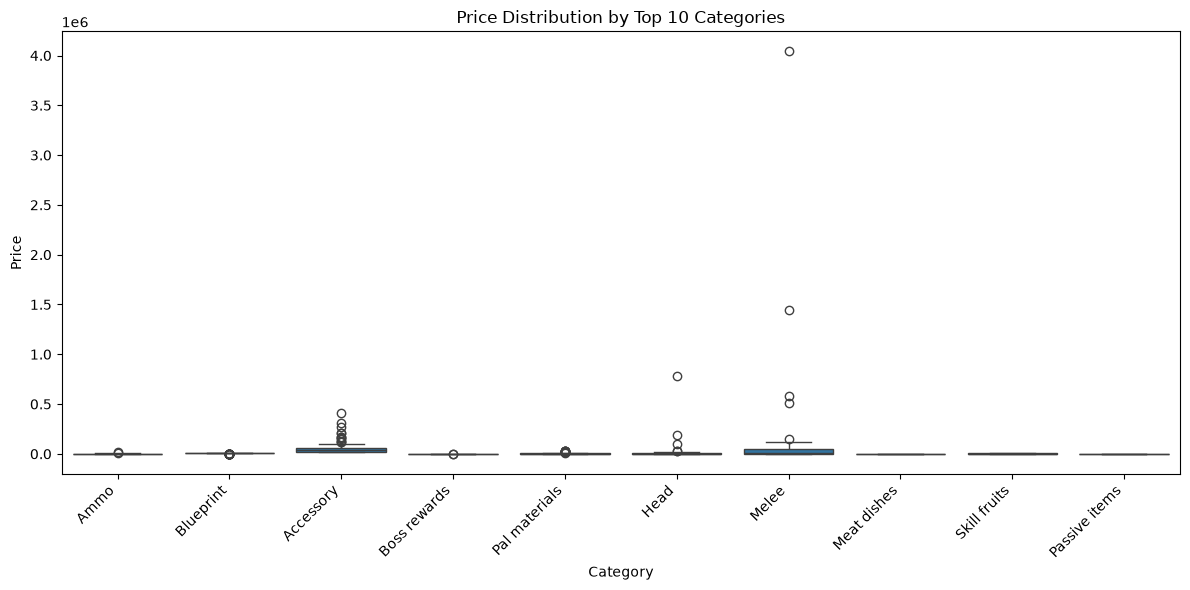

In [143]:
category_boxplot = df[
    ["category", "price"]
].dropna()

top_categories = (
    category_boxplot["category"]
    .value_counts()
    .head(10)
    .index
)

category_boxplot = category_boxplot[
    category_boxplot["category"]
    .isin(top_categories)
]

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=category_boxplot,
    x="category",
    y="price"
)

plt.xlabel("Category")
plt.ylabel("Price")
plt.title(
    "Price Distribution by Top 10 Categories"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

**Interpretasi:** Distribusi harga berbeda antar kategori dan beberapa kategori memiliki nilai ekstrem yang jauh lebih tinggi dibandingkan sebagian besar item lainnya. Hal ini menunjukkan bahwa harga item tidak tersebar secara merata pada setiap kategori.

### 6.3 Correlation Heatmap

Correlation heatmap digunakan untuk melihat hubungan linear antara atribut numerik.

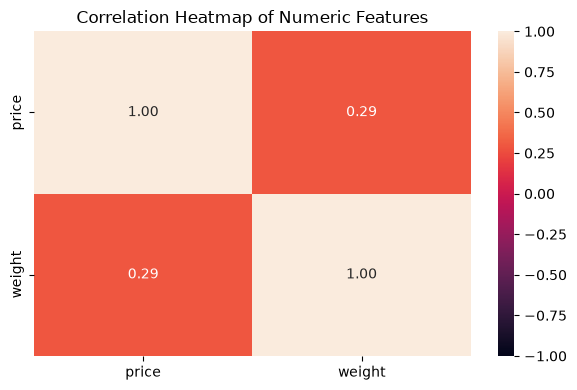

In [144]:
correlation_features = [
    "price",
    "weight"
]

corr_matrix = df[
    correlation_features
].corr()

plt.figure(figsize=(6, 4))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    vmin=-1,
    vmax=1
)

plt.title(
    "Correlation Heatmap of Numeric Features"
)

plt.tight_layout()
plt.show()

**Interpretasi:** Nilai korelasi antara price dan weight adalah sekitar 0,29, yang menunjukkan adanya hubungan linear positif tetapi relatif lemah. Artinya, peningkatan berat cenderung diikuti peningkatan harga, tetapi hubungan tersebut tidak kuat.

## 7. Ringkasan Hasil EDA

Bagian ini merangkum karakteristik dataset berdasarkan hasil statistik, missing value, outlier, dan korelasi antaratribut numerik.

In [145]:
# RINGKASAN HASIL EDA

print("===== DATASET =====")

print("Jumlah baris  :", df.shape[0])
print("Jumlah kolom :", df.shape[1])

print("\n===== FITUR UTAMA =====")

for feature in [
    "price",
    "weight",
    "stackable",
    "rarity",
    "category"
]:
    print("-", feature)

print("\n===== MISSING VALUE =====")

display(
    missing_summary
)

print("\n===== OUTLIER =====")

display(
    outlier_summary.round(2)
)

print("\n===== CORRELATION =====")

display(
    corr_matrix.round(3)
)

===== DATASET =====
Jumlah baris  : 1593
Jumlah kolom : 7

===== FITUR UTAMA =====
- price
- weight
- stackable
- rarity
- category

===== MISSING VALUE =====


,Missing Count,Missing Percentage (%)
price,142,8.91
name,0,0.00
weight,0,0.00
stackable,0,0.00
rarity,0,0.00
category,0,0.00
url,0,0.00



===== OUTLIER =====


,Atribut,Q1,Q3,IQR,Lower Bound,Upper Bound,Jumlah Outlier,Persentase (%)
0,price,290.0,10000.0,9710.0,-14275.0,24565.0,187,11.74
1,weight,0.0,1.0,1.0,-1.5,2.5,278,17.45



===== CORRELATION =====


,price,weight
price,1.000,0.291
weight,0.291,1.000


## 8. Kesimpulan

Berdasarkan hasil eksplorasi data (EDA) pada dataset item Palworld dari Paldex, diperoleh **1.593 observasi dan 7 atribut**. Lima atribut utama yang dianalisis adalah `price`, `weight`, `stackable`, `rarity`, dan `category`. Dataset telah melalui proses cleaning dan preprocessing agar data hasil scraping dapat digunakan untuk analisis statistik dan visualisasi.

Pada atribut numerik, `price` memiliki rata-rata sebesar **58.011,09 Gold** dengan median **10.000 Gold**, sedangkan `weight` memiliki rata-rata **2,82** dengan median **0**. Perbedaan nilai mean dan median pada `price` menunjukkan bahwa terdapat beberapa item dengan harga yang jauh lebih tinggi dibandingkan sebagian besar item lainnya. Hal ini juga terlihat pada distribusi harga yang didominasi oleh harga rendah hingga sekitar 10.000 Gold, sementara sebagian kecil item memiliki harga hingga jutaan Gold.

Pada atribut kategorikal, terdapat **1.263 item yang dapat ditumpuk (Yes)** dan **330 item yang tidak dapat ditumpuk (No)**. Berdasarkan atribut `rarity`, kategori **COMMON** memiliki jumlah item terbanyak, yaitu **452 item**, sedangkan kategori **UNCOMMON** memiliki jumlah paling sedikit, yaitu **250 item**. Untuk atribut `category`, **Blueprint** menjadi kategori dengan jumlah item terbanyak, yaitu **490 item**.

Hasil analisis missing value menunjukkan bahwa hanya atribut `price` yang memiliki nilai kosong, yaitu sebanyak **142 data atau 8,91%**. Atribut `weight`, `stackable`, `rarity`, dan `category` tidak memiliki missing value pada dataset final. Missing value pada `price` tidak langsung dihapus karena data tersebut masih dapat digunakan untuk analisis atribut lainnya. Untuk analisis yang membutuhkan `price`, data yang kosong diabaikan menggunakan `dropna()`.

Berdasarkan metode IQR, ditemukan **187 kandidat outlier pada `price` (11,74%)** dan **278 kandidat outlier pada `weight` (17,45%)**. Outlier tersebut tidak langsung dihapus karena nilai ekstrem masih dapat merupakan nilai yang valid pada item tertentu. Oleh karena itu, outlier dipertahankan dan digunakan sebagai bagian dari analisis distribusi data.

Hasil analisis hubungan antaratribut numerik menunjukkan bahwa korelasi antara `price` dan `weight` adalah **0,291**, yang menunjukkan hubungan linear positif tetapi relatif lemah. Artinya, item dengan berat lebih tinggi cenderung memiliki harga lebih tinggi, tetapi hubungan tersebut tidak kuat. Secara keseluruhan, hasil EDA menunjukkan bahwa dataset memiliki variasi yang cukup besar pada harga dan berat, serta memiliki distribusi kategori, rarity, dan status stackable yang beragam.

**Catatan:** angka **1.593**, **142 missing**, **187 outlier price**, dan **278 outlier weight** di atas berasal dari output terbaru notebook kamu. 
